# CLIP MultiModal

In [5]:
!pip cache purge --quiet

In [6]:
!pip install matplotlib==3.10.6 \
             open_clip_torch==3.2.0 --quiet

In [7]:
import json
import logging
import matplotlib.pyplot as plt
import numpy as np
import open_clip
import pandas as pd
import requests
import torch
import warnings
import zipfile

from io import BytesIO
from IPython.display import display
from PIL import Image

INFO:matplotlib.font_manager:generated new fontManager


In [9]:
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

In [10]:
# If you've forked this repo, change OWNER to your GitHub username.
# REPO and BRANCH will normally stay the same unless you renamed them.
OWNER = "singlestore-cookbook"
REPO = "singlestore-cookbook.github.io"
BRANCH = "refs/heads/main"

BASE_URL = f"https://raw.githubusercontent.com/{OWNER}/{REPO}/{BRANCH}/code/part-ai/multimodal-rag-working-with-text-images-and-audio/datasets"

In [11]:
zip_url = f"{BASE_URL}/pexels_images.zip"

response = requests.get(zip_url)
response.raise_for_status()

with open("pexels_images.zip", "wb") as f:
    f.write(response.content)

with zipfile.ZipFile("pexels_images.zip", "r") as z:
    z.extractall()

image_folder = "pexels_images"

print("Extracted images and folder structure preserved from zip file.")

Extracted images and folder structure preserved from zip file.


In [12]:
# Collect images and categories
image_paths = []
categories = []

for root, dirs, files in os.walk(image_folder):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            full_path = os.path.join(root, f)
            image_paths.append(full_path)
            categories.append(os.path.basename(root))

print(f"Found {len(image_paths)} images in {len(set(categories))} categories.")

Found 51 images in 6 categories.


In [13]:
# Load CLIP model (CPU)
device = "cpu"
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained = "openai"
)
model.to(device)
model.eval();

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [14]:
# Preprocess and encode images
processed_images = []
for path in image_paths:
    img = Image.open(path).convert("RGB")
    processed_images.append(preprocess(img).unsqueeze(0))

images_tensor = torch.cat(processed_images, dim = 0).to(device)

with torch.no_grad():
    image_embeddings = model.encode_image(images_tensor)

image_embeddings /= image_embeddings.norm(dim = -1, keepdim = True)

In [15]:
# Convert embeddings to NumPy float32
embedding_array = image_embeddings.cpu().numpy().astype("float32")

In [16]:
# Create Pandas DataFrame
df = pd.DataFrame({
    "category": categories,
    "image_path": image_paths,
    "embedding": list(embedding_array)
})

In [17]:
df.head()

,category,image_path,embedding
0,objects,pexels_images/objects/010_pexels-photo-4690297...,"[-0.030688463, 0.0076383133, 0.020822525, 0.02..."
1,objects,pexels_images/objects/006_pexels-photo-1236421...,"[0.017499289, 0.045329876, -0.022273855, 0.002..."
2,objects,pexels_images/objects/004_pexels-photo-346804....,"[-0.02301172, 0.006977425, -0.008972225, 0.016..."
3,objects,pexels_images/objects/005_pexels-photo-748600....,"[-0.01968281, -0.0011044039, 0.030012187, 0.00..."
4,objects,pexels_images/objects/008_pexels-photo-1409216...,"[-0.023330824, -0.011383818, -0.014190739, 0.0..."


In [18]:
# Only select the query image
df_query = df[df["category"] == "query"]

<div class="alert alert-block alert-warning">
    <b class="fa fa-solid fa-exclamation-circle"></b>
    <div>
        <p><b>Action Required</b></p>
        <p>Select the database from the drop-down menu at the top of this notebook. It updates the <b>connection_url</b> which is used by SQLAlchemy to make connections to the selected database.</p>
    </div>
</div>

In [19]:
from sqlalchemy import *

db_connection = create_engine(connection_url)

In [20]:
with db_connection.begin() as conn:
    conn.execute(text("TRUNCATE TABLE clip_images;"))

In [21]:
df[df["category"] != "query"].to_sql(
    "clip_images",
    con = db_connection,
    if_exists = "append",
    index = False,
    chunksize = 1000
)

print("Uploaded embeddings to SingleStore.")

Uploaded embeddings to SingleStore.


In [22]:
# Helper Functions
def get_text_embedding(text, model, device):
    """Encodes a text string into a CLIP embedding vector."""
    with torch.no_grad():
        text_tokens = open_clip.tokenize([text]).to(device)
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim = -1, keepdim = True)
        return text_features.cpu().numpy()[0].tolist()

def get_image_embedding(image_path, model, preprocess, device):
    """Encodes an image from a file path into a CLIP embedding vector."""
    img = Image.open(image_path).convert("RGB")
    image_input = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image_input)
        image_features /= image_features.norm(dim = -1, keepdim = True)
        return image_features.cpu().numpy()[0].tolist()

def run_similarity_search(embedding, db_connection, top_k = 5):
    # Ensure embedding is a float32 array and normalized
    if not isinstance(embedding, np.ndarray):
        embedding = np.array(embedding, dtype = "float32")
    else:
        embedding = embedding.astype("float32")
    embedding /= np.linalg.norm(embedding)

    # Convert to JSON for SingleStore
    embedding_json = json.dumps(embedding.tolist())

    sql = text("""
        SELECT category,
               image_path,
               embedding <*> :vector AS similarity_score
        FROM clip_images
        ORDER BY similarity_score DESC
        LIMIT :limit;
    """)

    return pd.read_sql(
        sql,
        con = db_connection,
        params = {"vector": embedding_json, "limit": top_k}
    )

def show_top_results(df):
    fig, axes = plt.subplots(1, len(df), figsize = (15, 5))
    for ax, (_, row) in zip(axes, df.iterrows()):
        ax.imshow(Image.open(row["image_path"]))
        ax.set_title(f"{row['category']}\nScore: {row['similarity_score']:.3f}")
        ax.axis("off")
    plt.show()

In [23]:
# Text Query
query_text = "A picture of a cat"

print(f"Running Text Query: '{query_text}'")

df_text_results = run_similarity_search(
    get_text_embedding(
        query_text,
        model,
        device
    ), db_connection
)

print("Text Query Results:")
df_text_results

Running Text Query: 'A picture of a cat'
Text Query Results:


,category,image_path,similarity_score
0,animals,pexels_images/animals/008_kitty-cat-kitten-pet...,0.269822
1,animals,pexels_images/animals/001_kittens-cat-cat-pupp...,0.238766
2,animals,pexels_images/animals/005_pexels-photo-792381....,0.224652
3,objects,pexels_images/objects/007_pexels-photo-733853....,0.221227
4,animals,pexels_images/animals/009_pexels-photo-814898....,0.215983


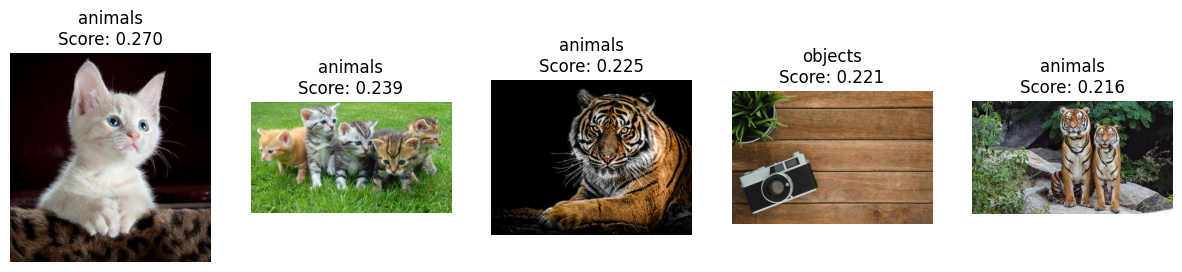

In [24]:
show_top_results(df_text_results)

In [25]:
# Image Query
# Select an image from the dataset to use as a query (e.g., the first one)
query_image_path = image_paths[0]

print(f"Running Image Query: {query_image_path}")

df_image_results1 = run_similarity_search(
    get_image_embedding(
        query_image_path,
        model,
        preprocess,
        device
    ), db_connection
)

print("Image Query Results:")
df_image_results1

Running Image Query: pexels_images/objects/010_pexels-photo-4690297.jpeg
Image Query Results:


,category,image_path,similarity_score
0,objects,pexels_images/objects/010_pexels-photo-4690297...,1.000000
1,objects,pexels_images/objects/007_pexels-photo-733853....,0.798297
2,objects,pexels_images/objects/008_pexels-photo-1409216...,0.782068
3,vehicles,pexels_images/vehicles/004_pexels-photo-117377...,0.728348
4,vehicles,pexels_images/vehicles/005_pexels-photo-799443...,0.728000


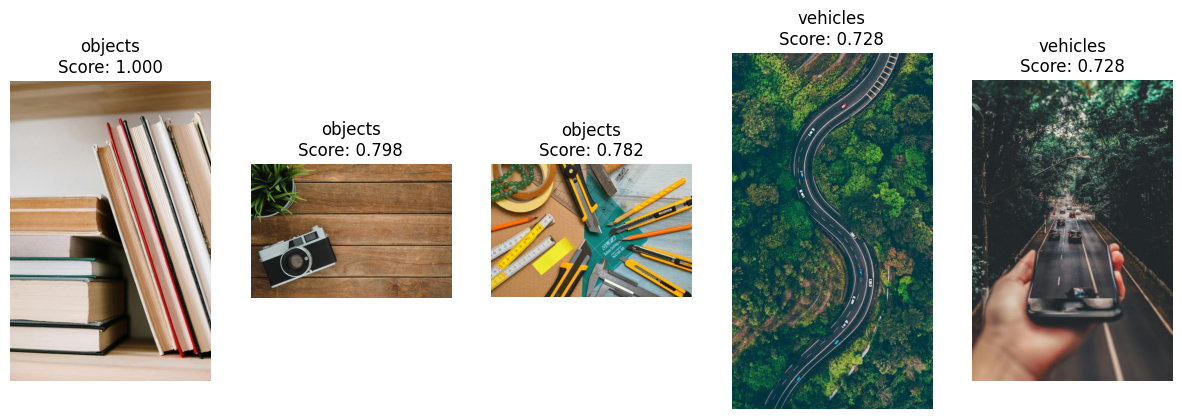

In [26]:
show_top_results(df_image_results1)

In [27]:
# Image Query
# Select an image from the dataset to use as a query (e.g., the in-memory one)
query_image_path = df_query.iloc[0]["image_path"]

print(f"Running Image Query: {query_image_path}")

df_image_results = run_similarity_search(
    get_image_embedding(
        query_image_path,
        model,
        preprocess,
        device
    ), db_connection,
    top_k = 4
)

df_image_results2 = pd.concat([
    df_query.assign(similarity_score = 1.0),
    df_image_results
], ignore_index = True)

df_image_results2 = df_image_results2.drop(
    columns = ["embedding"],
    errors = "ignore"
)

print("Image Query Results:")
df_image_results2

Running Image Query: pexels_images/query/001_pexels-pixabay-159711.jpg
Image Query Results:


,category,image_path,similarity_score
0,query,pexels_images/query/001_pexels-pixabay-159711.jpg,1.000000
1,objects,pexels_images/objects/010_pexels-photo-4690297...,0.907405
2,objects,pexels_images/objects/007_pexels-photo-733853....,0.764003
3,objects,pexels_images/objects/008_pexels-photo-1409216...,0.727475
4,objects,pexels_images/objects/006_pexels-photo-1236421...,0.713141


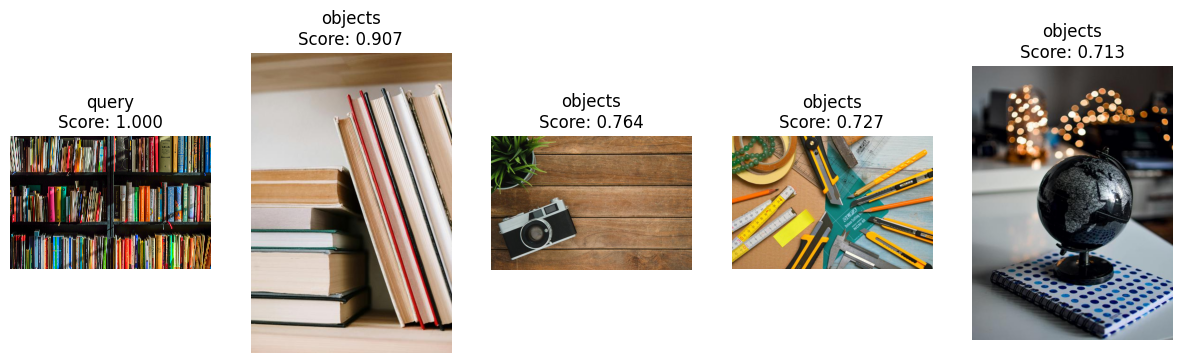

In [28]:
show_top_results(df_image_results2)